
# Chapter 8 — IoT Impact on Industry and Society
## Hands-On Python Practice

**Fundamentals of the Internet of Things**  
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

This notebook studies **system-level impact**, not a particular sensor, protocol, or cloud platform. Each exercise asks the same engineering question in a different domain:

> **Does connected observation improve a measurable outcome, and what counter-metric prevents a misleading conclusion?**

The exercises use synthetic data so that the baseline and the IoT-enabled policy can be compared under controlled conditions. The models are intentionally simple enough to inspect, but they make their assumptions explicit and separate **observation**, **decision rules**, and **outcomes**.

### Exercises
1. **Smart waste collection** — noisy fill measurements, a causal one-day forecast, and dispatch thresholds.
2. **Smart manufacturing** — periodic sampling, continuous sampling, and persistence logic as separate changes.
3. **Adaptive street lighting** — energy savings with both missed detections and false-positive occupancy detections.
4. **Remote patient monitoring** — observation frequency separated from alarm persistence.

All pseudo-random generators use explicit seeds. Default results are accompanied by repeated simulations to show how much conclusions vary across plausible random realisations. The values are educational simulation parameters, not operational recommendations for a city, factory, utility, or healthcare provider.


In [1]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
FIG_DPI = 180

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)


def qrange(values, qs=(0.05, 0.50, 0.95)):
    """Compact 5th/median/95th-percentile summary."""
    arr = np.asarray(values, dtype=float)
    return np.quantile(arr, qs)


NumPy: 2.4.4
pandas: 3.0.2



## Exercise 8.1 — Smart Waste Collection: Fixed Schedule vs. Fill-Aware Dispatch

### Background
The simulated system represents a **small urban district with 48 monitored containers**, not an entire city. Container coordinates are expressed in kilometres relative to a depot. The purpose is to study information and dispatch decisions without turning the exercise into a full vehicle-routing problem.

A connected controller should not know the future waste stream. It therefore receives only:

- a noisy fill-level measurement at the daily 06:00 planning time;
- the history of earlier measurements and known collection events;
- an exponentially weighted moving-average (EWMA) estimate of the **daily fill increment**.

The controller forecasts the next-day fill as `current measured fill + estimated daily increment`. The future generated waste is used **only after the fact** to calculate forecast error; it is never passed to the dispatch rule.

### Policies
- **Fixed daily:** collect all containers every day at 06:00.
- **Fill-aware:** collect when measured fill is at least 72%, or when the one-day EWMA forecast reaches 95%.

### Explicit simplifications
The route is a nearest-neighbour tour from and back to one depot. Truck capacity, service time, traffic, multiple vehicles, and route time windows are deliberately excluded. Sensor noise is Gaussian with a standard deviation of 1.8 percentage points of container capacity. These assumptions make the causal comparison transparent rather than operationally complete.


In [2]:

def nearest_neighbor_route(points, depot=(0.0, 0.0)):
    """Approximate a closed route through selected 2-D points."""
    if len(points) == 0:
        return 0.0
    remaining = [tuple(p) for p in points]
    current = tuple(depot)
    distance = 0.0
    while remaining:
        arr = np.asarray(remaining)
        d = np.sqrt(((arr - np.asarray(current)) ** 2).sum(axis=1))
        j = int(np.argmin(d))
        nxt = remaining.pop(j)
        distance += float(d[j])
        current = nxt
    return distance + math.dist(current, depot)


def generate_waste_scenario(seed=8, n_bins=48, days=21):
    rng = np.random.default_rng(seed)
    positions = np.column_stack([
        rng.uniform(0.4, 5.5, n_bins),
        rng.uniform(-2.5, 2.5, n_bins),
    ])
    hidden_hourly_rates = rng.uniform(0.006, 0.014, n_bins)
    initial_fill = rng.uniform(0.05, 0.45, n_bins)

    H = days * 24
    h = np.arange(H)
    diurnal = 0.72 + 0.45 * (1 + np.sin(2 * np.pi * (h - 9) / 24)) / 2
    weekly = 1.0 + 0.10 * np.sin(2 * np.pi * h / (24 * 7))
    random_factor = rng.lognormal(
        mean=-0.5 * 0.32**2, sigma=0.32, size=(H, n_bins)
    )
    increments = (
        diurnal[:, None]
        * weekly[:, None]
        * hidden_hourly_rates[None, :]
        * random_factor
    )
    sensor_noise = rng.normal(0, 0.018, size=(H, n_bins))
    return positions, initial_fill, increments, sensor_noise


def run_waste_policy(
    scenario, policy="fixed", current_threshold=0.72,
    forecast_threshold=0.95, ewma_alpha=0.45
):
    positions, initial_fill, increments, sensor_noise = scenario
    H, n_bins = increments.shape

    true_fill = initial_fill.copy()
    daily_gain_est = np.full(n_bins, 0.22)  # coarse prior, fraction/day
    last_reference = np.zeros(n_bins)
    have_previous = False

    route_km = 0.0
    overflow_bin_hours = 0
    collection_fills = []
    collections = 0
    forecast_errors = []

    for t in range(H):
        true_fill += increments[t]
        overflow_bin_hours += int((true_fill > 1.0).sum())
        true_fill = np.minimum(true_fill, 1.18)  # bookkeeping margin

        if t % 24 != 6:
            continue

        measured = np.clip(true_fill + sensor_noise[t], 0, 1.18)

        if have_previous:
            observed_gain = np.maximum(0.0, measured - last_reference)
            observed_gain = np.clip(observed_gain, 0, 0.60)
            daily_gain_est = (
                (1 - ewma_alpha) * daily_gain_est
                + ewma_alpha * observed_gain
            )

        forecast = np.clip(measured + daily_gain_est, 0, 1.30)

        # Evaluation only. This realised future is never visible to the controller.
        # Forecast MAE is meaningful only for the policy that actually consults
        # the forecast; the fixed schedule never reads it.
        if policy == "fill-aware" and t + 24 < H:
            realised_no_service = true_fill + increments[t + 1:t + 25].sum(axis=0)
            forecast_errors.extend(np.abs(forecast - realised_no_service).tolist())

        if policy == "fixed":
            idx = np.arange(n_bins)
        elif policy == "fill-aware":
            idx = np.where(
                (measured >= current_threshold)
                | (forecast >= forecast_threshold)
            )[0]
        else:
            raise ValueError(policy)

        if len(idx):
            collection_fills.extend(true_fill[idx].tolist())
            collections += len(idx)
            route_km += nearest_neighbor_route(positions[idx])
            true_fill[idx] = 0.0

        # The system knows which bins it has just serviced.
        last_reference = measured.copy()
        last_reference[idx] = 0.0
        have_previous = True

    return {
        "Route distance (km)": route_km,
        "Container collections": collections,
        "Mean fill at collection": np.mean(collection_fills),
        "Overflow bin-hours": overflow_bin_hours,
        "Forecast MAE (fill fraction)": (
            np.mean(forecast_errors) if forecast_errors else np.nan
        ),
    }


waste_scenario = generate_waste_scenario(seed=8)
waste_fixed = run_waste_policy(waste_scenario, "fixed")
waste_dynamic = run_waste_policy(waste_scenario, "fill-aware")

waste_summary = pd.DataFrame([
    {"Policy": "Fixed daily", **waste_fixed},
    {"Policy": "Fill-aware", **waste_dynamic},
])
waste_summary


,Policy,Route distance (km),Container collections,Mean fill at collection,Overflow bin-hours,Forecast MAE (fill fraction)
0,Fixed daily,784.513,1008,0.232,0,NaN
1,Fill-aware,422.659,275,0.812,7,0.032


Robustness: 5th / median / 95th percentiles


,Route reduction (%),Collection reduction (%),Overflow bin-hours,Forecast MAE (percentage points)
0.050,41.878,71.915,0.000,2.939
0.500,46.547,73.413,2.500,3.079
0.950,52.980,74.901,14.850,3.251


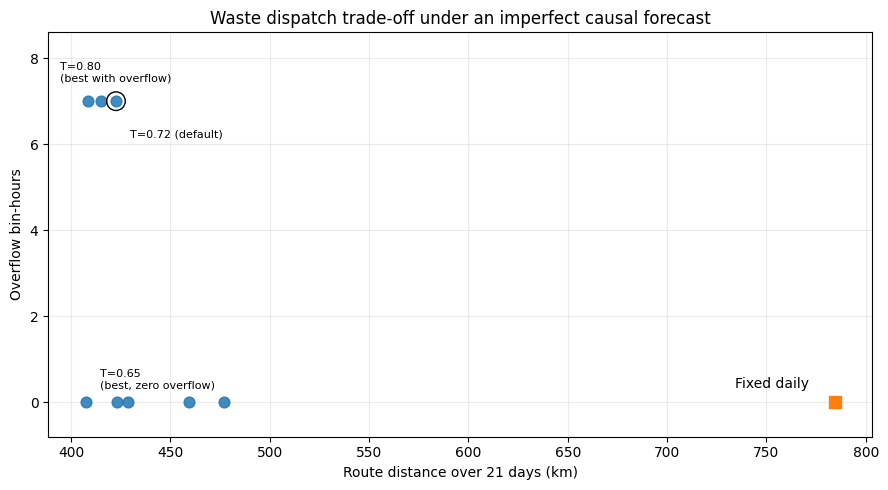

,Current threshold,Route distance (km),Container collections,Mean fill at collection,Overflow bin-hours,Forecast MAE (fill fraction)
0,0.500,477.036,365,0.611,0,0.032
1,0.550,459.436,333,0.667,0,0.032
2,0.600,428.878,306,0.725,0,0.032
3,0.650,407.388,287,0.770,0,0.032
4,0.700,423.206,276,0.802,0,0.032
5,0.720,422.659,275,0.812,7,0.032
6,0.750,415.114,272,0.820,7,0.032
7,0.800,408.611,267,0.829,7,0.032


In [3]:

# Threshold sweep on the same underlying district and waste stream.
# The range is chosen to stay below the point where the forecast
# trigger (>= 0.95) becomes the binding constraint for almost every
# container; beyond that point, raising the current-fill threshold
# further has essentially no effect, which would otherwise collapse
# several points onto the same route/overflow coordinates.
waste_thresholds = np.array([0.50, 0.55, 0.60, 0.65, 0.70, 0.72, 0.75, 0.80])
waste_sweep_rows = []
for thr in waste_thresholds:
    r = run_waste_policy(
        waste_scenario, "fill-aware", current_threshold=float(thr)
    )
    waste_sweep_rows.append({"Current threshold": thr, **r})
waste_sweep = pd.DataFrame(waste_sweep_rows)

# Robustness: paired fixed-vs-connected comparisons on 50 new scenarios.
waste_rep_rows = []
for seed in range(100, 150):
    scenario = generate_waste_scenario(seed=seed)
    fixed = run_waste_policy(scenario, "fixed")
    dynamic = run_waste_policy(scenario, "fill-aware")
    waste_rep_rows.append({
        "seed": seed,
        "Route reduction (%)": 100 * (
            1 - dynamic["Route distance (km)"] / fixed["Route distance (km)"]
        ),
        "Collection reduction (%)": 100 * (
            1 - dynamic["Container collections"] / fixed["Container collections"]
        ),
        "Overflow bin-hours": dynamic["Overflow bin-hours"],
        "Forecast MAE (percentage points)": 100 * dynamic["Forecast MAE (fill fraction)"],
    })
waste_robustness = pd.DataFrame(waste_rep_rows)
print("Robustness: 5th / median / 95th percentiles")
display(waste_robustness.drop(columns="seed").quantile([0.05, 0.50, 0.95]))

# Deliberately a scatter, not a connected line: the threshold is not a
# continuous dial a reader should picture sweeping smoothly between
# these eight simulated points, and a connecting line would suggest a
# smoother trade-off than the model actually produces.
fig, ax = plt.subplots(figsize=(9, 5.0))
ax.scatter(
    waste_sweep["Route distance (km)"],
    waste_sweep["Overflow bin-hours"],
    s=60, alpha=0.85, zorder=3,
)

# Label only the default policy and the two most informative extreme
# points: the best zero-overflow threshold, and the best threshold
# once some overflow is already being accepted.
label_specs = [
    (0.65, "T=0.65\n(best, zero overflow)", (10, 10)),
    (0.72, "T=0.72 (default)", (10, -26)),
    (0.80, "T=0.80\n(best with overflow)", (-20, 14)),
]
for threshold, label, offset in label_specs:
    row = waste_sweep.iloc[
        np.argmin(np.abs(waste_sweep["Current threshold"] - threshold))
    ]
    ax.annotate(
        label,
        (row["Route distance (km)"], row["Overflow bin-hours"]),
        xytext=offset, textcoords="offset points", fontsize=8,
    )
ax.scatter(
    waste_fixed["Route distance (km)"],
    waste_fixed["Overflow bin-hours"],
    marker="s", s=80, zorder=3,
)
ax.annotate(
    "Fixed daily",
    (waste_fixed["Route distance (km)"], waste_fixed["Overflow bin-hours"]),
    xytext=(-72, 10), textcoords="offset points",
)
default_row = waste_sweep.iloc[np.argmin(np.abs(waste_sweep["Current threshold"] - 0.72))]
ax.scatter(default_row["Route distance (km)"], default_row["Overflow bin-hours"], s=180, facecolors="none", edgecolors="black", zorder=4)
ax.set_xlabel("Route distance over 21 days (km)")
ax.set_ylabel("Overflow bin-hours")
ax.set_title("Waste dispatch trade-off under an imperfect causal forecast")
ax.set_ylim(-0.8, 8.6)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("fig_8_1_waste.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

waste_sweep



### Analysis
The default fill-aware policy reduces route distance and the number of service stops, but its forecast is estimated only from earlier noisy observations, never from the hidden future rate. Overflow can occur when the estimate is wrong or demand changes faster than the EWMA can follow. That is precisely the trade-off a real deployment must manage.

The threshold sweep is more informative than a single favourable percentage: more aggressive collection can suppress overflow at the cost of additional route distance, while higher thresholds accept more service risk. The repeated simulations show whether the conclusion survives changes in the synthetic district rather than depending on one lucky seed.

#### Challenge tasks
1. Change the EWMA coefficient from 0.2 to 0.8. How does forecast responsiveness affect route distance and overflow?
2. Increase sensor noise from 1.8 to 4 percentage points of capacity. Which threshold becomes preferable?
3. Add a truck-capacity limit and compare the current nearest-neighbour route with a capacity-aware heuristic.
4. Replace the independent bin growth rates with a neighbourhood event that temporarily increases waste generation in a subset of containers.



## Exercise 8.2 — Smart Manufacturing: Separating Sampling Frequency from Decision Logic

### Background
A production line experiences gradual drift and occasional shocks. The connected system can observe the process more often, but **sampling frequency** and **alarm logic** are different mechanisms. To avoid attributing both effects to “continuous monitoring,” this exercise compares three policies under the same exogenous disturbances and the same measurement-noise sequence:

1. **Periodic, single crossing:** inspect every 4 hours; intervene after one threshold crossing.
2. **Continuous, single crossing:** inspect every 10 minutes with the **same threshold and the same single-crossing rule**. This isolates the value of temporal coverage.
3. **Continuous, persistence-2:** inspect every 10 minutes but require two consecutive crossings. Comparing policies 2 and 3 isolates the effect of persistence logic.

Every intervention resets the process and causes 30 minutes of planned downtime.

### Metric definition
The chapter reports the **good-output fraction of scheduled capacity**

\[
G = \frac{\text{good units}}{\text{nominal rate} \times \text{scheduled intervals}}.
\]

This is not full Overall Equipment Effectiveness (OEE). In this deliberately simplified model it equals `Availability × Quality` because a separate performance-loss factor is fixed at 1. We therefore avoid calling it OEE.


In [4]:

def generate_manufacturing_scenario(seed=18, days=30, dt_min=10, rate=100):
    rng = np.random.default_rng(seed)
    T = days * 24 * 60 // dt_min

    drift = rng.normal(0.008, 0.020, T)
    shock_mask = rng.random(T) < 0.012
    shocks = np.zeros(T)
    shocks[shock_mask] = (
        rng.choice([-1, 1], shock_mask.sum())
        * rng.uniform(0.30, 0.85, shock_mask.sum())
    )

    disturbances = drift + shocks
    measurement_noise = rng.normal(0, 0.16, T)  # one common stream
    defect_uniforms = rng.random((T, rate))      # one common stream
    return disturbances, measurement_noise, defect_uniforms


def run_manufacturing_policy(
    scenario, mode="periodic", threshold=1.0, persistence=1,
    inspect_every=24, downtime_steps=3, rate=100, dt_min=10
):
    disturbances, measurement_noise, defect_uniforms = scenario
    T = len(disturbances)

    x = 0.0
    downtime_left = 0
    interventions = 0
    defective = 0
    produced = 0
    consecutive = 0

    for t in range(T):
        if downtime_left > 0:
            downtime_left -= 1
            continue

        x = 0.99 * x + disturbances[t]
        p_defect = 0.004 + 0.20 / (1 + np.exp(-4 * (abs(x) - 0.65)))
        defective += int((defect_uniforms[t] < p_defect).sum())
        produced += rate

        inspect = (mode == "continuous") or (t % inspect_every == 0)
        if inspect:
            high = abs(x + measurement_noise[t]) > threshold
            consecutive = consecutive + 1 if high else 0
            if consecutive >= persistence:
                interventions += 1
                x = 0.0
                downtime_left = downtime_steps
                consecutive = 0
        elif mode == "periodic":
            consecutive = 0

    good = produced - defective
    scheduled_capacity = rate * T
    return {
        "Good units": good,
        "Defective units": defective,
        "Interventions": interventions,
        "Downtime (min)": interventions * downtime_steps * dt_min,
        "Quality": good / produced,
        "Availability": produced / scheduled_capacity,
        "Good-output fraction": good / scheduled_capacity,
        "Defect rate": defective / produced,
    }


mfg_scenario = generate_manufacturing_scenario(seed=18)
mfg_results = {
    "Periodic 4 h, single": run_manufacturing_policy(
        mfg_scenario, mode="periodic", persistence=1
    ),
    "Continuous, single": run_manufacturing_policy(
        mfg_scenario, mode="continuous", persistence=1
    ),
    "Continuous, persistence-2": run_manufacturing_policy(
        mfg_scenario, mode="continuous", persistence=2
    ),
}
mfg_summary = pd.DataFrame([
    {"Policy": name, **result} for name, result in mfg_results.items()
])
mfg_summary


,Policy,Good units,Defective units,Interventions,Downtime (min),Quality,Availability,Good-output fraction,Defect rate
0,"Periodic 4 h, single",401935,25865,14,420,0.940,0.990,0.930,0.060
1,"Continuous, single",403240,20660,27,810,0.951,0.981,0.933,0.049
2,"Continuous, persistence-2",403956,22944,17,510,0.946,0.988,0.935,0.054


Robustness: 5th / median / 95th percentiles


Good-output fraction  Defect rate (%)  \
Policy                                                                   
Continuous, persistence-2 0.050                 0.916            5.705   
                          0.500                 0.923            6.355   
                          0.950                 0.930            7.000   
Continuous, single        0.050                 0.922            4.903   
                          0.500                 0.928            5.205   
                          0.950                 0.934            5.688   
Periodic 4 h, single      0.050                 0.905            6.461   
                          0.500                 0.916            7.384   
                          0.950                 0.925            8.239   

                                 Downtime (h)  
Policy                                         
Continuous, persistence-2 0.050         7.500  
                          0.500        10.250  
                          0.950        13.275  
Continuous, single        0.050        11.000  
                          0.500        14.500  
                          0.950        18.275  
Periodic 4 h, single      0.050         6.000  
                          0.500         8.000  
                          0.950        10.500

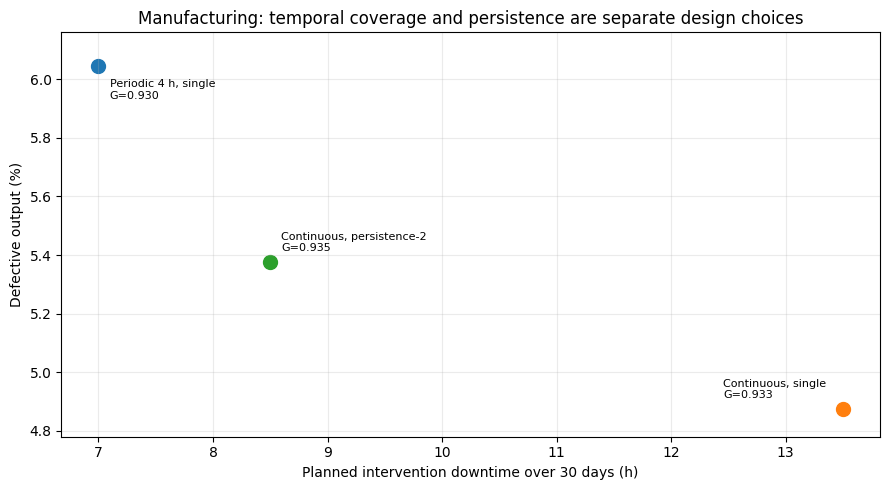

In [5]:

# Robustness over 50 paired process realisations.
mfg_rep_rows = []
for seed in range(100, 150):
    scenario = generate_manufacturing_scenario(seed=seed)
    policies = {
        "Periodic 4 h, single": ("periodic", 1),
        "Continuous, single": ("continuous", 1),
        "Continuous, persistence-2": ("continuous", 2),
    }
    for name, (mode, p) in policies.items():
        r = run_manufacturing_policy(scenario, mode=mode, persistence=p)
        mfg_rep_rows.append({
            "seed": seed,
            "Policy": name,
            "Good-output fraction": r["Good-output fraction"],
            "Defect rate (%)": 100 * r["Defect rate"],
            "Downtime (h)": r["Downtime (min)"] / 60,
        })
mfg_robustness = pd.DataFrame(mfg_rep_rows)
print("Robustness: 5th / median / 95th percentiles")
display(
    mfg_robustness.groupby("Policy")[[
        "Good-output fraction", "Defect rate (%)", "Downtime (h)"
    ]].quantile([0.05, 0.50, 0.95])
)

fig, ax = plt.subplots(figsize=(9, 5.0))
label_offsets = {
    "Periodic 4 h, single": (8, -24),
    "Continuous, single": (-86, 8),
    "Continuous, persistence-2": (8, 8),
}
for _, row in mfg_summary.iterrows():
    x = row["Downtime (min)"] / 60
    y = 100 * row["Defect rate"]
    ax.scatter(x, y, s=100)
    ax.annotate(
        f"{row['Policy']}\nG={row['Good-output fraction']:.3f}",
        (x, y), xytext=label_offsets[row["Policy"]],
        textcoords="offset points", fontsize=8,
    )
ax.set_xlabel("Planned intervention downtime over 30 days (h)")
ax.set_ylabel("Defective output (%)")
ax.set_title("Manufacturing: temporal coverage and persistence are separate design choices")
ax.set_ylim(4.78, 6.16)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("fig_8_2_manufacturing.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()



### Analysis
The first comparison is causal by construction: periodic and continuous-single policies use the same threshold and the same single-crossing rule, so their difference is primarily **when measurements are available**. Continuous sampling catches some excursions earlier, reducing defects, but it also creates more interventions and planned downtime.

The second comparison keeps continuous observation fixed and changes only the decision rule. Requiring persistence suppresses some interventions but allows some short excursions to continue longer. The good-output fraction therefore depends on the balance between avoided scrap and intervention downtime; no rule is guaranteed to dominate every random realisation. The 50-replication summary makes that uncertainty visible.

#### Challenge tasks
1. Increase intervention duration from 30 to 60 minutes and find when periodic inspection becomes preferable in good-output fraction.
2. Sweep the common threshold while holding persistence fixed. Plot defect rate against downtime.
3. Assign a cost per defective unit and a cost per downtime minute. Does the economically preferred policy match the policy with the largest good-output fraction?
4. Add a separate performance-loss factor (slower cycle rate under drift) and then compute a full `Availability × Performance × Quality` OEE value.



## Exercise 8.3 — Adaptive Street Lighting: Energy Savings vs. Service Quality

### Background
Three policies control 300 street lamps for one simulated week in 15-minute intervals. The occupancy-aware controller uses imperfect sensing in **both directions**:

- sensitivity = 95% for true occupancy;
- false-positive probability = 0.8% per unoccupied lamp during a night interval.

A detection raises the local lamp to full power and adjacent lamps to at least 60%, while the network otherwise remains at 20% standby.

### Explicit simplifications
Occupancy events are independent Bernoulli events across lamps and intervals; a real pedestrian would create spatially and temporally correlated occupancy. Electrical power is assumed to scale linearly with the commanded dimming level. These assumptions are adequate for the trade-off exercise but are not a photometric or traffic model.

A **service miss** occurs when true occupancy exists but the local lamp is below 60%. False-positive detections waste energy but do not count as service misses.


In [6]:

def simulate_lighting(
    seed=23, n_lamps=300, days=7, dt_h=0.25, power_w=80,
    sensitivity=0.95, false_positive=0.008
):
    rng = np.random.default_rng(seed)
    T = int(days * 24 / dt_h)
    t = np.arange(T) * dt_h
    hour = t % 24
    night = (hour >= 18) | (hour < 6)

    p_occ = np.where(
        (hour >= 18) & (hour < 23), 0.12,
        np.where((hour >= 23) | (hour < 1), 0.05,
                 np.where(hour < 6, 0.018, 0.0))
    )
    occupancy = rng.random((T, n_lamps)) < p_occ[:, None]

    sensitivity_draw = rng.random((T, n_lamps))
    false_positive_draw = rng.random((T, n_lamps))
    detected = (
        (occupancy & (sensitivity_draw < sensitivity))
        | ((~occupancy) & night[:, None] & (false_positive_draw < false_positive))
    )

    levels = {}
    levels["Fixed"] = np.repeat(night[:, None], n_lamps, axis=1).astype(float)

    scheduled = np.where(
        ~night, 0.0,
        np.where((hour >= 18) & (hour < 23), 0.75, 0.45)
    )
    levels["Time schedule"] = np.repeat(scheduled[:, None], n_lamps, axis=1)

    adaptive = np.repeat(np.where(night, 0.20, 0.0)[:, None], n_lamps, axis=1)
    for i in range(n_lamps):
        active = detected[:, i] & night
        adaptive[active, i] = 1.0
        if i > 0:
            adaptive[active, i - 1] = np.maximum(adaptive[active, i - 1], 0.60)
        if i < n_lamps - 1:
            adaptive[active, i + 1] = np.maximum(adaptive[active, i + 1], 0.60)
    levels["Occupancy-aware"] = adaptive

    demand = occupancy & night[:, None]
    rows = []
    for name, L in levels.items():
        energy = (L * power_w * dt_h / 1000).sum()
        miss = ((L < 0.60) & demand).sum() / max(demand.sum(), 1)
        rows.append({
            "Policy": name,
            "Energy (kWh/week)": energy,
            "Service-miss rate": miss,
        })
    return pd.DataFrame(rows)


lighting_summary = simulate_lighting(seed=23)
lighting_summary


,Policy,Energy (kWh/week),Service-miss rate
0,Fixed,"2,016.000",0.000
1,Time schedule,"1,159.200",0.236
2,Occupancy-aware,615.072,0.042


Robustness: 5th / median / 95th percentiles


Energy saving (%)  Service misses (%)
Policy                                                      
Fixed           0.050              0.000               0.000
                0.500              0.000               0.000
                0.950              0.000               0.000
Occupancy-aware 0.050             69.487               3.623
                0.500             69.658               4.081
                0.950             69.845               4.439
Time schedule   0.050             42.500              23.130
                0.500             42.500              23.963
                0.950             42.500              24.629

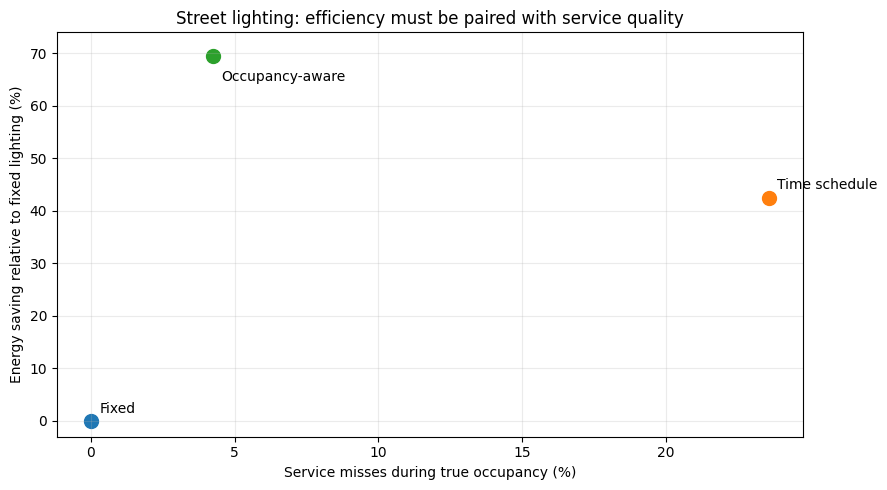

In [7]:

# Robustness across 50 weeks with new occupancy and sensor outcomes.
lighting_rep_rows = []
for seed in range(100, 150):
    df = simulate_lighting(seed=seed)
    fixed_energy = float(df.loc[df["Policy"] == "Fixed", "Energy (kWh/week)"].iloc[0])
    for _, row in df.iterrows():
        lighting_rep_rows.append({
            "seed": seed,
            "Policy": row["Policy"],
            "Energy saving (%)": 100 * (1 - row["Energy (kWh/week)"] / fixed_energy),
            "Service misses (%)": 100 * row["Service-miss rate"],
        })
lighting_robustness = pd.DataFrame(lighting_rep_rows)
print("Robustness: 5th / median / 95th percentiles")
display(
    lighting_robustness.groupby("Policy")[[
        "Energy saving (%)", "Service misses (%)"
    ]].quantile([0.05, 0.50, 0.95])
)

fixed_energy = float(
    lighting_summary.loc[lighting_summary["Policy"] == "Fixed", "Energy (kWh/week)"].iloc[0]
)
fig, ax = plt.subplots(figsize=(9, 5.0))
lighting_offsets = {
    "Fixed": (6, 6),
    "Time schedule": (6, 6),
    "Occupancy-aware": (6, -18),
}
for _, row in lighting_summary.iterrows():
    saving = 100 * (1 - row["Energy (kWh/week)"] / fixed_energy)
    miss = 100 * row["Service-miss rate"]
    ax.scatter(miss, saving, s=100)
    ax.annotate(
        row["Policy"], (miss, saving),
        xytext=lighting_offsets[row["Policy"]], textcoords="offset points"
    )
ax.set_xlabel("Service misses during true occupancy (%)")
ax.set_ylabel("Energy saving relative to fixed lighting (%)")
ax.set_title("Street lighting: efficiency must be paired with service quality")
ax.set_ylim(-3, 74)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("fig_8_3_lighting.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()



### Analysis
The occupancy-aware controller pays an energy penalty for false-positive detections, so its energy result is not based on a one-sided “sensor can only miss” assumption. It still saves substantial energy in the default model, while service misses are driven mainly by false negatives.

The figure intentionally reports both sides of the decision. A time schedule can save energy without any sensing, but it cannot react to unexpected late-night occupancy. Conversely, a sensor-driven policy can preserve service while wasting some energy on false detections. The best policy depends on how the municipality values energy, public-space service, equipment life, and maintenance complexity.

#### Challenge tasks
1. Sweep standby level from 10% to 50% and plot energy saving against service-miss rate.
2. Sweep sensor sensitivity and false-positive rate separately. Which error type has the larger effect on which KPI?
3. Replace independent occupancy with a pedestrian who moves along adjacent lamps for several intervals.
4. Add a rebound scenario in which lower operating cost causes one extra hour of nightly operation and recalculate net energy saving.



## Exercise 8.4 — Remote Patient Monitoring: Separating Observation Frequency from Alarm Logic

### Background
This exercise uses a **synthetic physiological score with no clinical interpretation**. One thousand patient-days are simulated at ten-minute intervals, and 8% contain a gradual deterioration event.

Three policies make the causal comparison explicit:

1. **Spot checks, single crossing:** four observations per day at 08:00, 12:00, 16:00, and 20:00.
2. **Continuous, single crossing:** all ten-minute observations with the **same threshold and same single-crossing rule**. Comparing policies 1 and 2 isolates temporal coverage.
3. **Continuous, persistence-2:** the same continuous observations but two consecutive crossings are required. Comparing policies 2 and 3 isolates alarm persistence.

The default threshold is 2.6 arbitrary score units.

### Metric definition
The simulator stops after the first alert on a patient-day. Therefore the burden metric is **false-alert patient-days per 100 patient-days**, not the total number of alarm notifications. Detection delay is reported **only among detected true events**; missed events are represented separately by the detection rate.


In [8]:

def generate_remote_monitoring(
    seed=31, n_days=1000, interval_min=10,
    event_prob=0.08, noise_scale=0.9
):
    rng = np.random.default_rng(seed)
    n = 24 * 60 // interval_min
    time_h = np.arange(n) * interval_min / 60

    X = np.zeros((n_days, n))
    for d in range(n_days):
        innovations = rng.normal(0, noise_scale, n)
        for k in range(1, n):
            X[d, k] = 0.6 * X[d, k - 1] + innovations[k]
        X[d] *= 0.8

    events = rng.random(n_days) < event_prob
    event_start = np.full(n_days, -1, dtype=int)
    for d in np.where(events)[0]:
        s = rng.integers(6 * 60 // interval_min, 20 * 60 // interval_min)
        event_start[d] = s
        # A deterioration event is finite: it rises over roughly 1.5-2.5 h,
        # holds at a randomly drawn severity for a short plateau (roughly
        # 1-3 h), and then recovers back toward baseline over roughly
        # 1-2.5 h. Severity, plateau length, and recovery length all vary
        # independently across events, so a brief event can genuinely
        # start and finish between two four-hour spot checks.
        amplitude = rng.uniform(2.1, 3.4)
        rise_len = int(rng.integers(9, 15))
        hold_len = int(rng.integers(6, 19))
        decay_len = int(rng.integers(6, 15))

        rise_end = min(s + rise_len, n)
        ramp = np.linspace(0.4, amplitude, rise_end - s)
        X[d, s:rise_end] += ramp

        hold_end = min(rise_end + hold_len, n)
        if hold_end > rise_end:
            X[d, rise_end:hold_end] += amplitude

        decay_end = min(hold_end + decay_len, n)
        if decay_end > hold_end:
            decay = np.linspace(amplitude, 0.0, decay_end - hold_end)
            X[d, hold_end:decay_end] += decay
        # After decay_end, the signal has fully returned to ordinary
        # baseline noise; the event no longer has any lasting effect.

    return X, time_h, events, event_start


def alert_fires(x, mode, threshold, persistence, interval_min=10):
    """Boolean array over the day: True at sample k exactly when the
    decision rule (single crossing, or persistence) is first satisfied
    at that sample -- the moment an alert episode begins, not every
    sample for which the rule remains satisfied afterward."""
    n = len(x)
    fires = np.zeros(n, dtype=bool)
    if mode == "spot":
        idx = np.array([8, 12, 16, 20]) * 60 // interval_min
        fires[idx] = x[idx] > threshold
        return fires
    run = 0
    for k in range(n):
        run = run + 1 if x[k] > threshold else 0
        if run == persistence:
            fires[k] = True
    return fires


def detect_remote(X, event_start, mode, threshold=2.6, persistence=1, interval_min=10):
    """For every patient-day, find the first alert at or after the true
    event onset (the detection), and separately flag whether an earlier,
    premature alert also fired before the event began."""
    n_days, n = X.shape
    first_post = np.full(n_days, -1, dtype=int)
    pre_alert = np.zeros(n_days, dtype=bool)
    any_alert = np.zeros(n_days, dtype=bool)
    for d in range(n_days):
        fires = alert_fires(X[d], mode, threshold, persistence, interval_min)
        idxs = np.flatnonzero(fires)
        any_alert[d] = idxs.size > 0
        s = event_start[d]
        if s >= 0:
            post = idxs[idxs >= s]
            pre = idxs[idxs < s]
            if post.size:
                first_post[d] = int(post[0])
            pre_alert[d] = pre.size > 0
    return first_post, pre_alert, any_alert


def remote_metrics(first_post, pre_alert, any_alert, events, event_start, interval_min=10):
    n_days = len(events)
    detected = (first_post >= 0) & events
    tp = int(detected.sum())
    fn = int((events & ~detected).sum())
    # A false-alert patient-day is either (a) a non-event day with any
    # alert, or (b) an event day whose first alert fired before the true
    # onset -- a premature call that a clinician would still have to
    # act on, even though the day is later credited with a true detection.
    fp_nonevent = int((any_alert & ~events).sum())
    fp_preevent = int((pre_alert & events).sum())
    fp = fp_nonevent + fp_preevent
    delays = [
        (first_post[d] - event_start[d]) * interval_min
        for d in np.where(detected)[0]
    ]
    return {
        "Detection rate": tp / max(int(events.sum()), 1),
        "False-alert patient-days / 100": 100 * fp / n_days,
        "Median delay among detected events (min)": float(np.median(delays)) if delays else np.nan,
        "TP": tp, "FP": fp, "FN": fn,
    }


rpm_X, rpm_time, rpm_events, rpm_start = generate_remote_monitoring(seed=31)
rpm_policies = {
    "Spot checks, single": ("spot", 1),
    "Continuous, single": ("continuous", 1),
    "Continuous, persistence-2": ("continuous", 2),
}
rpm_results = {}
for name, (mode, p) in rpm_policies.items():
    first_post, pre_alert, any_alert = detect_remote(rpm_X, rpm_start, mode, threshold=2.6, persistence=p)
    rpm_results[name] = remote_metrics(first_post, pre_alert, any_alert, rpm_events, rpm_start)

rpm_summary = pd.DataFrame([
    {"Policy": name, **result} for name, result in rpm_results.items()
])
rpm_summary


,Policy,Detection rate,False-alert patient-days / 100,Median delay among detected events (min),TP,FP,FN
0,"Spot checks, single",0.406,0.800,145.000,26,8,38
1,"Continuous, single",0.984,20.300,70.000,63,203,1
2,"Continuous, persistence-2",0.953,3.000,90.000,61,30,3


Robustness: 5th / median / 95th percentiles


Detection rate  \
Policy                                            
Continuous, persistence-2 0.050           0.895   
                          0.500           0.943   
                          0.950           0.976   
Continuous, single        0.050           0.975   
                          0.500           1.000   
                          0.950           1.000   
Spot checks, single       0.050           0.320   
                          0.500           0.411   
                          0.950           0.527   

                                 False-alert patient-days / 100  \
Policy                                                            
Continuous, persistence-2 0.050                           2.000   
                          0.500                           2.600   
                          0.950                           3.155   
Continuous, single        0.050                          18.390   
                          0.500                          20.150   
                          0.950                          22.355   
Spot checks, single       0.050                           0.300   
                          0.500                           0.700   
                          0.950                           1.155   

                                 Median delay among detected events (min)  
Policy                                                                     
Continuous, persistence-2 0.050                                   100.000  
                          0.500                                   105.000  
                          0.950                                   110.000  
Continuous, single        0.050                                    70.000  
                          0.500                                    80.000  
                          0.950                                    90.000  
Spot checks, single       0.050                                   130.000  
                          0.500                                   157.500  
                          0.950                                   180.000

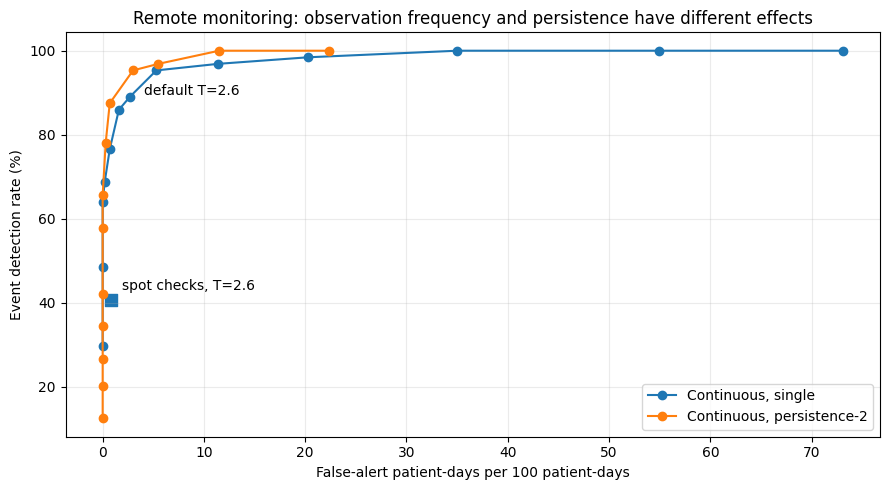

,Policy,Threshold,Detection rate,False-alert patient-days / 100
3,"Continuous, single",2.600,0.984,20.300
16,"Continuous, persistence-2",2.600,0.953,3.000


In [9]:

# Threshold curves for both continuous decision rules.
thresholds = np.arange(2.0, 4.41, 0.2)
rpm_sweep_rows = []
for p, label in [(1, "Continuous, single"), (2, "Continuous, persistence-2")]:
    for thr in thresholds:
        first_post, pre_alert, any_alert = detect_remote(
            rpm_X, rpm_start, "continuous", threshold=float(thr), persistence=p
        )
        m = remote_metrics(first_post, pre_alert, any_alert, rpm_events, rpm_start)
        rpm_sweep_rows.append({
            "Policy": label,
            "Threshold": thr,
            "Detection rate": m["Detection rate"],
            "False-alert patient-days / 100": m["False-alert patient-days / 100"],
        })
rpm_sweep = pd.DataFrame(rpm_sweep_rows)

# Robustness across 50 new cohorts.
rpm_rep_rows = []
for seed in range(100, 150):
    X, _, events, starts = generate_remote_monitoring(seed=seed)
    for name, (mode, p) in rpm_policies.items():
        first_post, pre_alert, any_alert = detect_remote(X, starts, mode, threshold=2.6, persistence=p)
        m = remote_metrics(first_post, pre_alert, any_alert, events, starts)
        rpm_rep_rows.append({"seed": seed, "Policy": name, **m})
rpm_robustness = pd.DataFrame(rpm_rep_rows)
print("Robustness: 5th / median / 95th percentiles")
display(
    rpm_robustness.groupby("Policy")[[
        "Detection rate",
        "False-alert patient-days / 100",
        "Median delay among detected events (min)",
    ]].quantile([0.05, 0.50, 0.95])
)

fig, ax = plt.subplots(figsize=(9, 5.0))
for label in ["Continuous, single", "Continuous, persistence-2"]:
    d = rpm_sweep[rpm_sweep["Policy"] == label]
    ax.plot(
        d["False-alert patient-days / 100"],
        100 * d["Detection rate"],
        marker="o", label=label,
    )

# Highlight the exact default persistence-2 point T=2.6.
default = rpm_sweep[
    (rpm_sweep["Policy"] == "Continuous, persistence-2")
    & np.isclose(rpm_sweep["Threshold"], 2.6)
].iloc[0]
ax.scatter(
    default["False-alert patient-days / 100"],
    100 * default["Detection rate"],
    s=180, facecolors="none",
)
ax.annotate(
    "default T=2.6",
    (default["False-alert patient-days / 100"], 100 * default["Detection rate"]),
    xytext=(8, -18), textcoords="offset points",
)

spot = rpm_results["Spot checks, single"]
ax.scatter(
    spot["False-alert patient-days / 100"],
    100 * spot["Detection rate"], marker="s", s=80,
)
ax.annotate(
    "spot checks, T=2.6",
    (spot["False-alert patient-days / 100"], 100 * spot["Detection rate"]),
    xytext=(8, 7), textcoords="offset points",
)

ax.set_xlabel("False-alert patient-days per 100 patient-days")
ax.set_ylabel("Event detection rate (%)")
ax.set_title("Remote monitoring: observation frequency and persistence have different effects")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig("fig_8_4_remote_monitoring.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

rpm_sweep[np.isclose(rpm_sweep["Threshold"], 2.6)]



### Analysis
The comparison separates two effects. Moving from four spot checks to continuous **single-crossing** monitoring changes only temporal coverage, and it improves detection substantially in this synthetic cohort, but it also creates many more false-alert days. Adding a two-sample persistence rule leaves temporal coverage unchanged and sharply reduces the false-alert burden, at the price of a longer median delay; because event severity now varies from day to day, persistence occasionally misses a borderline event outright rather than detecting it late.

The threshold figure highlights the default `T = 2.6` persistence-2 point, so the coordinates reported in the results table are directly visible on the plotted curve. Because deterioration severity is no longer a single fixed value, both continuous curves now decline smoothly as the threshold rises, giving a genuine detection-versus-false-alert trade-off rather than a near-vertical step at 100% detection.

#### Challenge tasks
1. Repeat the threshold sweep for persistence values 1, 2, and 3.
2. Reduce event prevalence from 8% to 2%. Explain why operational attention to false alerts becomes more important even if sensitivity is unchanged.
3. Replace the “one alert per patient-day” service model with alert episodes and a refractory period, then count total notifications.
4. Add missing samples or communication outages and compare the effect on spot and continuous policies.

> **Clinical caution:** none of the score values, thresholds, event models, or alert policies in this notebook should be interpreted as clinical guidance.



## Practice Section Summary

Across all four exercises, the connected system is evaluated as a **decision system**, not as a collection of devices. The recurring workflow is:

1. Define a baseline and a common workload.
2. State exactly what information the connected system receives.
3. Change one design mechanism at a time where causal interpretation matters.
4. Measure a benefit and a counter-metric.
5. Report a default realisation **and** repeated simulations to expose uncertainty.
6. Treat favourable percentages as properties of the model, not universal promises.

This structure is reusable in later chapters when the book moves from system-level impact to specific sensors, acquisition chains, processing methods, and communication technologies.
